In [2]:
import numpy as np
from estimation import _calculate_statistics, _analyze_threshold_trends
import matplotlib.pyplot as plt
import os



from masking import make_inclusion_mask
from processing import get_maps, prepare_maps
from configuration import get_file_config
from estimation import plot_extrapolation_estimate
from logger import setup_logger
from monster import  apply_config, apply_config_rsEGFP2

%load_ext autoreload
%autoreload 2

logger = setup_logger()


2026-02-19 16:40:17,985: logger: INFO: Imposing high_resolution_limit: 2.6 (processing.py:37)


0 11_100us/100us
1 9_10us/10us
3 7_30ns/30ns
5 3_300ps/300ps
6 10_30us/30us
7 2_3ps/3ps
8 4_1ns/1ns
10 8_1us/1us
13 6_10ns/10ns
14 5_3ns/3ns
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/7_30ns/30ns_deposit.mtz


2026-02-19 16:40:19,846: logger: INFO: this is calculate_again True (processing.py:94)
2026-02-19 16:40:19,847: logger: INFO: loading: 0.07, tv_weight: 0.005807665501203384, only_kweighted: True (processing.py:115)


2026-02-19 16:40:19 [info     ] Computing difference map.     
2026-02-19 16:40:19 [info     ]   using fixed                  kparameter=0.07


2026-02-19 16:40:19,890: logger: INFO: Diffmap std: 0.005 (processing.py:274)
2026-02-19 16:40:19,891: logger: INFO: diffmap larger voxel count: 0.2894371141975309 (processing.py:275)
2026-02-19 16:40:19,954: logger: INFO: ignore_mask voxel count: 0.5746728395061729 (processing.py:217)
2026-02-19 16:40:19,963: logger: INFO: Shift value 0.31973 corresponds to zero frequency 450570.750 (processing.py:231)
2026-02-19 16:40:19,987: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:282)
2026-02-19 16:40:20,047: logger: INFO: ignore_mask voxel count: 0.7384506172839507 (processing.py:217)
2026-02-19 16:40:20,059: logger: INFO: Shift value 0.31692 corresponds to zero frequency 446617.500 (processing.py:231)
2026-02-19 16:40:20,083: logger: INFO: calculating autoshift for triggered map... done (processing.py:286)
2026-02-19 16:40:20,084: logger: INFO: Diffmap zero frequency was not set (processing.py:304)
2026-02-19 16:40:20,107: logger: WARNING: Diffmap M

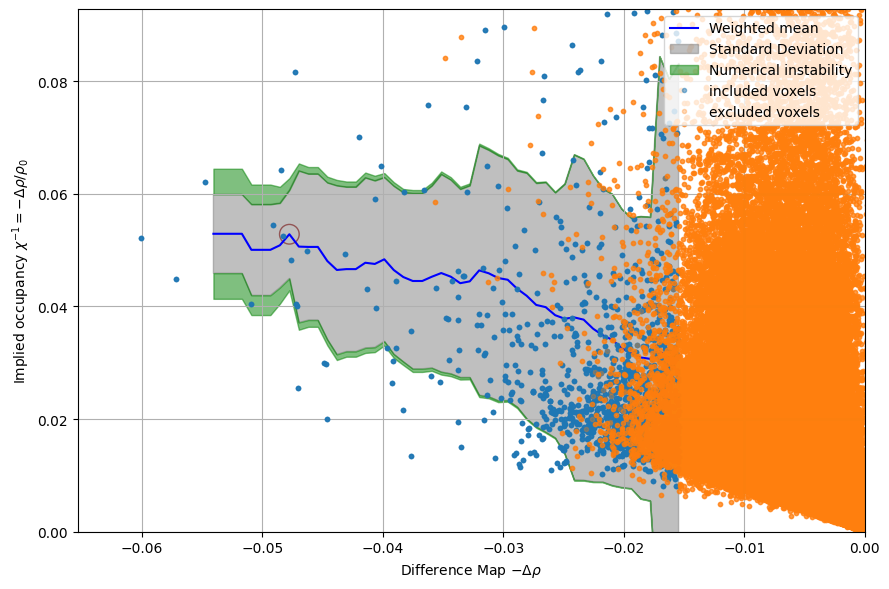

In [10]:


config = apply_config()
config["map_processing"]["dark_mean_correction"] = True
config["map_processing"]["diffmap_mean_correction"] = False
config["map_processing"]["diffmap_v2_correction"] = True
config["map_processing"]["diffmap_type"] = "kweighted"
config['masking']['dark_size_threshold'] = 0
unscaled_dark, unscaled_triggered = get_maps(config)
diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
logger.warning(f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}")
inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
# diffmap_np, map_dark_np = _prepare_maps(
#     diffmap, map_dark, map_dark_comp, info_container, params
# )
fig, ax = plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)

# fig.savefig("../tex2/figs/PL_tv.png")
# plt.show()




2026-02-19 16:33:09,544: logger: INFO: Imposing high_resolution_limit: 1.6 (processing.py:37)
2026-02-19 16:33:11,872: logger: INFO: this is calculate_again True (processing.py:94)
2026-02-19 16:33:11,873: logger: INFO: loading: 0.17, tv_weight: 0.007515095428704186, only_kweighted: False (processing.py:115)


2026-02-19 16:33:12 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-02-19 16:33:12 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-02-19 16:33:12 [info     ] Computing difference map.     
2026-02-19 16:33:12 [info     ]   using fixed                  kparameter=0.17
2026-02-19 16:33:12 [info     ] TV denoising with fixed weight weight=0.007515095428704186
2026-02-19 16:33:14 [info     ] Map TV-denoised with fixed weight final_negentropy=7.35e-02 initial_negentropy=-9.35e-05 weight=0.007515095428704186


2026-02-19 16:33:14,274: logger: INFO: diffmap has uncertainties: True (processing.py:157)
2026-02-19 16:33:14,291: logger: INFO: Diffmap std: 0.002 (processing.py:274)
2026-02-19 16:33:14,292: logger: INFO: diffmap larger voxel count: 0.24967997685185186 (processing.py:275)
2026-02-19 16:33:14,340: logger: INFO: ignore_mask voxel count: 0.4218263888888889 (processing.py:217)
2026-02-19 16:33:14,346: logger: INFO: Shift value 0.32986 corresponds to zero frequency 77710.844 (processing.py:231)
2026-02-19 16:33:14,367: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:282)
2026-02-19 16:33:14,413: logger: INFO: ignore_mask voxel count: 0.5675798611111111 (processing.py:217)
2026-02-19 16:33:14,420: logger: INFO: Shift value 0.32889 corresponds to zero frequency 77482.227 (processing.py:231)
2026-02-19 16:33:14,441: logger: INFO: calculating autoshift for triggered map... done (processing.py:286)
2026-02-19 16:33:14,442: logger: INFO: this is calculat

2026-02-19 16:33:14 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-02-19 16:33:15 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-02-19 16:33:15 [info     ] Computing difference map.     
2026-02-19 16:33:15 [info     ]   using fixed                  kparameter=0.17
2026-02-19 16:33:15 [info     ] TV denoising with fixed weight weight=0.007515095428704186
2026-02-19 16:33:16 [info     ] Map TV-denoised with fixed weight final_negentropy=2.02e-02 initial_negentropy=1.60e-04 weight=0.007515095428704186


2026-02-19 16:33:16,833: logger: INFO: diffmap has uncertainties: True (processing.py:157)
2026-02-19 16:33:16,835: logger: INFO: Diffmap zero frequency: 0.005540370941162109 (processing.py:302)
2026-02-19 16:33:16,851: logger: WARNING: Diffmap Mean: -0.000000, Std: 0.006007 (3175241889.py:10)
2026-02-19 16:33:16,877: logger: WARNING: Used threshold for posmask: 0.399, found 1445 blobs (masking.py:133)
2026-02-19 16:33:16,880: logger: INFO: Using blobs with more than 22.00452891919375(3 A^3) voxels (masking.py:150)
2026-02-19 16:33:16,880: logger: INFO: Maximum Blob sizes found: 64 (masking.py:151)
2026-02-19 16:33:16,899: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of shape (7, 7, 7), considering a total of 92 voxels (control via 'blocking_radius' parameter) (masking.py:182)
2026-02-19 16:33:17,038: logger: INFO: Excluding 0 (0.00%) voxels from mask due to positive density within 1.5 A and above the 99 percentile (control via 'blocki

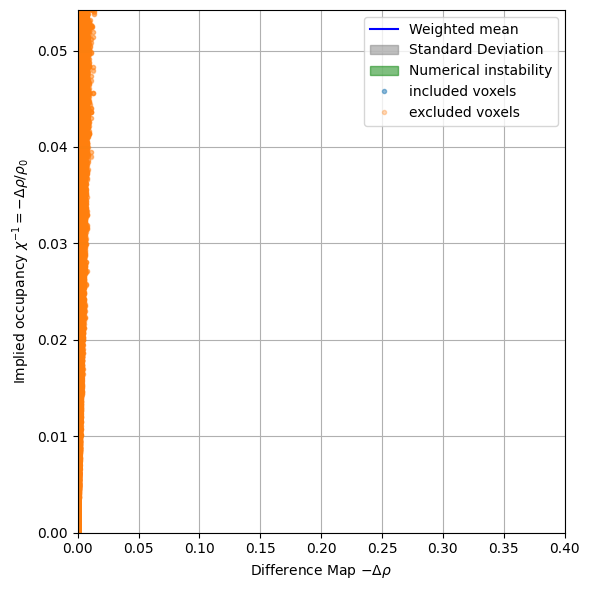

In [4]:
config = apply_config_rsEGFP2()
config["map_processing"]["diffmap_mean_correction"] = False
config["map_processing"]["dark_mean_correction"] = True
config["map_processing"]["diffmap_v2_correction"] = False
config["masking"]["blocking_percentile"] = 99
unscaled_dark, unscaled_triggered = get_maps(config)
diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
logger.warning(f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}")
inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
# diffmap_np, map_dark_np = _prepare_maps(
#     diffmap, map_dark, map_dark_comp, info_container, params
# )
fig, ax = plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)
ax.set_xlim(0, 0.4)
plt.show()
fig.savefig("../tex2/figs/rsEGFP2_tv.png")




In [ ]:
config = apply_config_rsEGFP2()
config["map_processing"]["diffmap_mean_correction"] = False
config["map_processing"]["dark_mean_correction"] = True
config["map_processing"]["diffmap_v2_correction"] = False
config["map_processing"][""] = False
config["masking"]["blocking_percentile"] = 99
unscaled_dark, unscaled_triggered = get_maps(config)
diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
logger.warning(f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}")
inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
# diffmap_np, map_dark_np = _prepare_maps(
#     diffmap, map_dark, map_dark_comp, info_container, params
# )
fig, ax = plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)
ax.set_xlim(0, 0.4)
plt.show()
fig.savefig("../tex2/figs/rsEGFP2_tv.png")





In [ ]:
config = apply_config_rsEGFP2()
config["map_processing"]["diffmap_mean_correction"] = False
config["map_processing"]["dark_mean_correction"] = True
config["map_processing"]["diffmap_v2_correction"] = False
config["map_processing"][""] = False
config["masking"]["blocking_percentile"] = 99
unscaled_dark, unscaled_triggered = get_maps(config)
diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
logger.warning(f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}")
inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
# diffmap_np, map_dark_np = _prepare_maps(
#     diffmap, map_dark, map_dark_comp, info_container, params
# )
fig, ax = plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)
ax.set_xlim(0, 0.4)
plt.show()
fig.savefig("../tex2/figs/rsEGFP2_tv.png")




